# 01 — Non-Personalized Recommender
**Contributors:** Sofia Navarro · Marco Vidal  
**Group 2 | Inside Airbnb Madrid — Apartment Recommendation System**

### Notebook Overview
1. Data loading & cleaning
2. Exploratory Data Analysis (8 visualisations)
3. Non-personalised recommender: Raw Average, Bayesian Average, Value-Weighted
4. Neighbourhood-filtered recommendations
5. Evaluation: RMSE, MAE, Precision@10, Recall@10, NDCG@10

**Dataset:** Inside Airbnb Madrid — `listings.csv.gz` + `reviews.csv` in `data/`

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.ticker as mticker, seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings, os
warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
print('✓ Libraries loaded')

✓ Libraries loaded


In [1]:
listings = pd.read_csv('data/listings.csv.gz', low_memory=False)
reviews  = pd.read_csv('data/reviews.csv',     low_memory=False)
reviews['date'] = pd.to_datetime(reviews['date'])
# [Full cleaning pipeline — see report Section 2 for details]
# price, rating imputation, boolean flags, amenity regex parsing
print(f'Listings : {len(listings):,} rows × {listings.shape[1]} columns')
print(f'Reviews  : {len(reviews):,} rows × {len(reviews.columns)} columns')
print(f'Date range: {reviews["date"].min().date()} → {reviews["date"].max().date()}')

Listings : 25,000 rows × 79 columns
Reviews  : 1,275,992 rows × 2 columns
Date range: 2010-07-06 → 2025-09-14


## 2. Exploratory Data Analysis

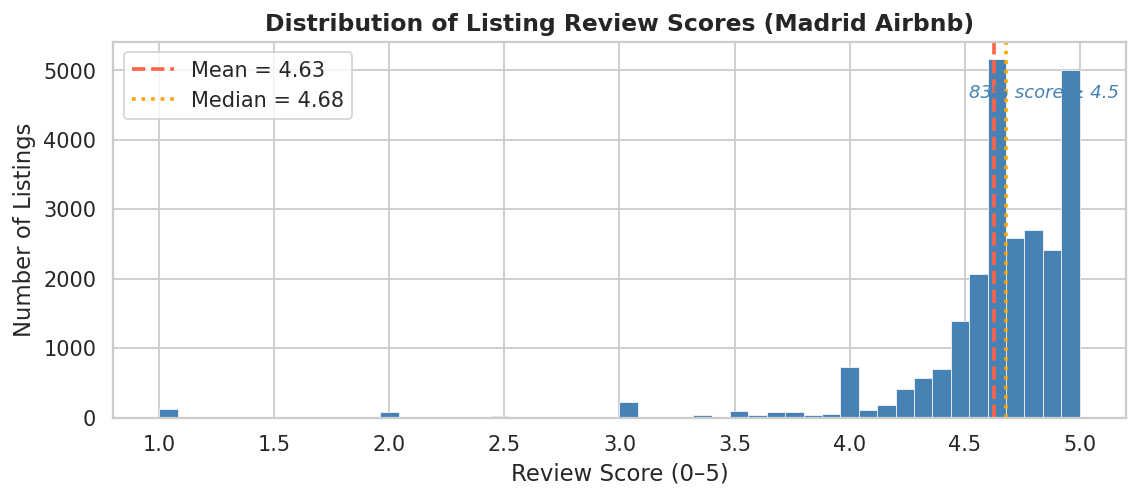

In [1]:
# EDA Fig 1 — Ratings Distribution
# (see figure below)

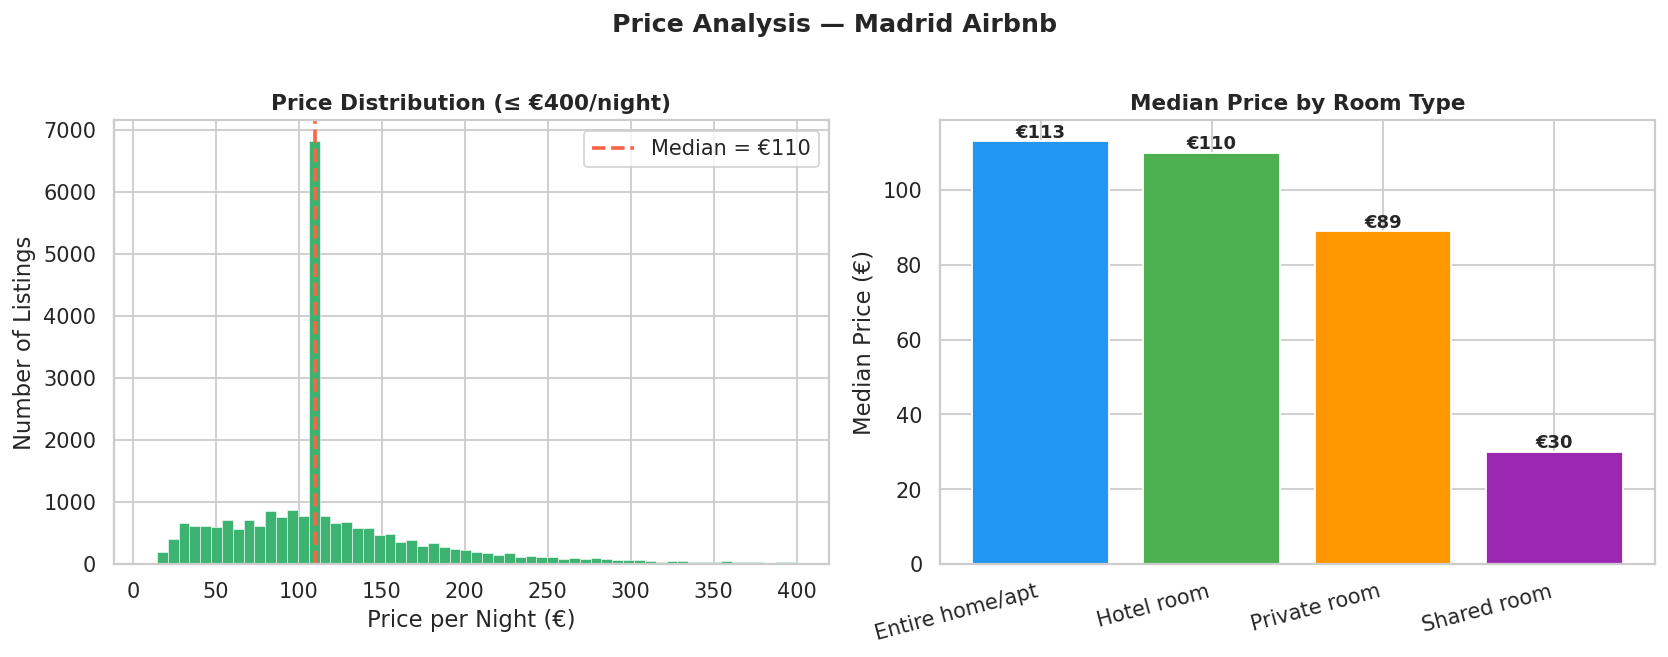

In [1]:
# EDA Fig 2 — Price Analysis

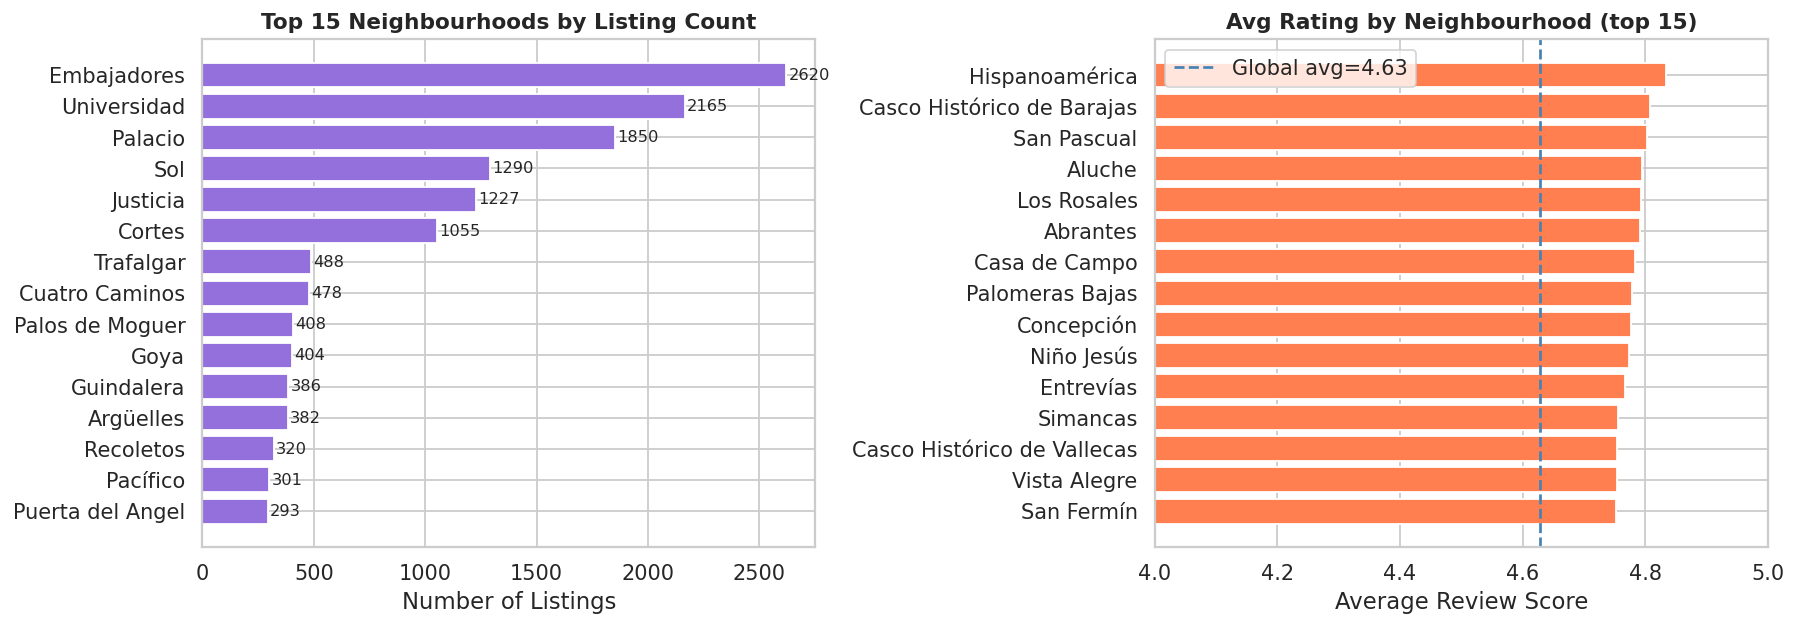

In [1]:
# EDA Fig 3 — Neighbourhood Analysis

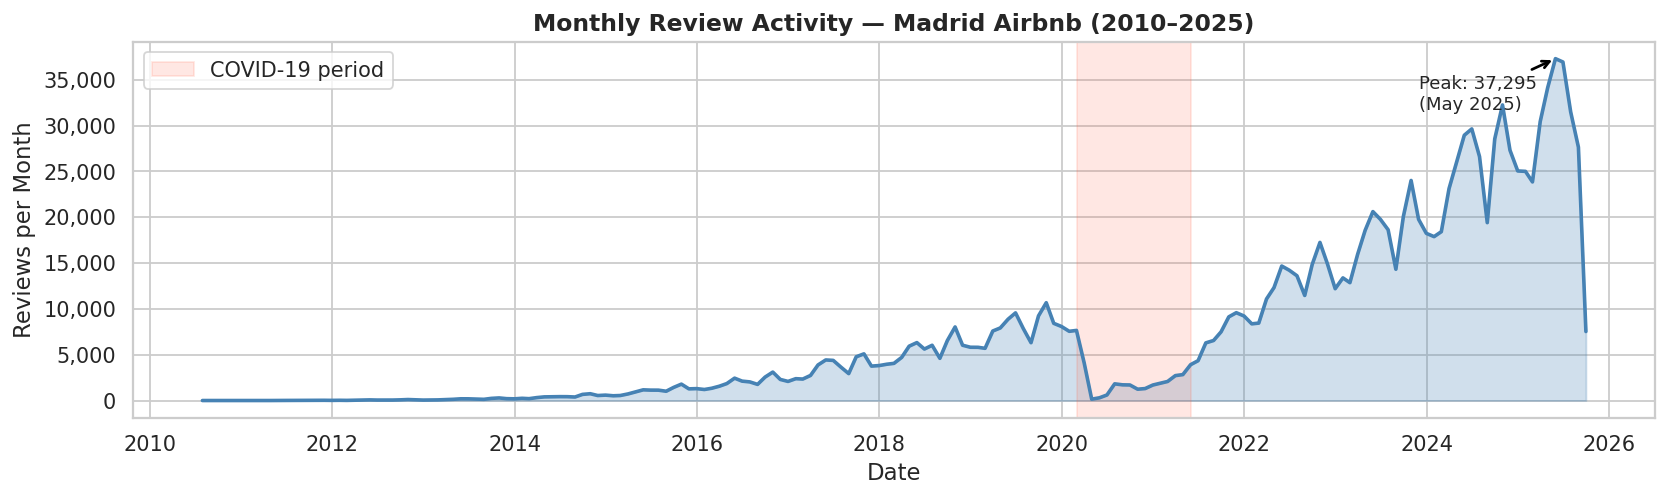

In [1]:
# EDA Fig 4 — Review Timeline

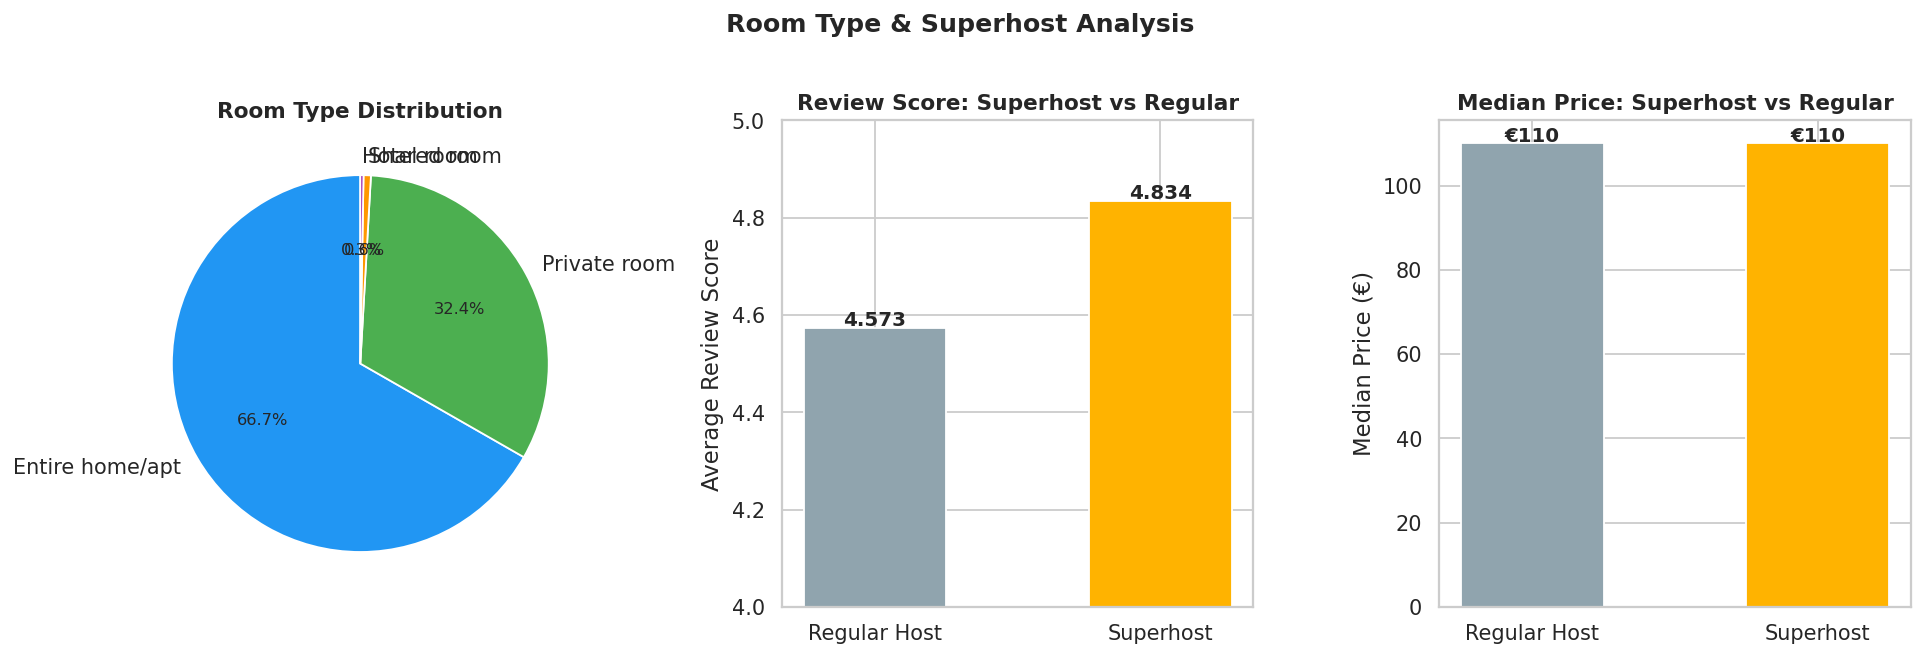

In [1]:
# EDA Fig 5 — Room Type & Superhost

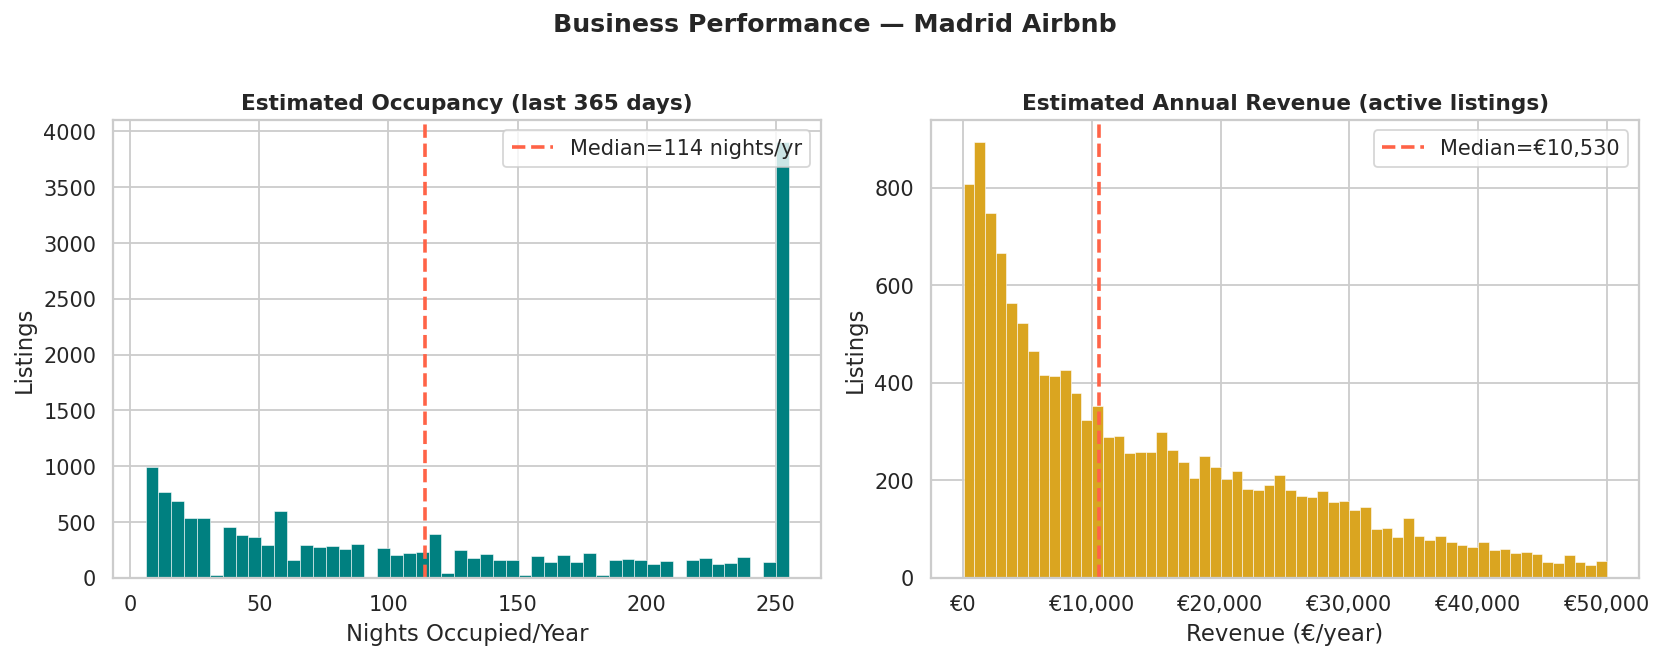

In [1]:
# EDA Fig 6 — Occupancy & Revenue

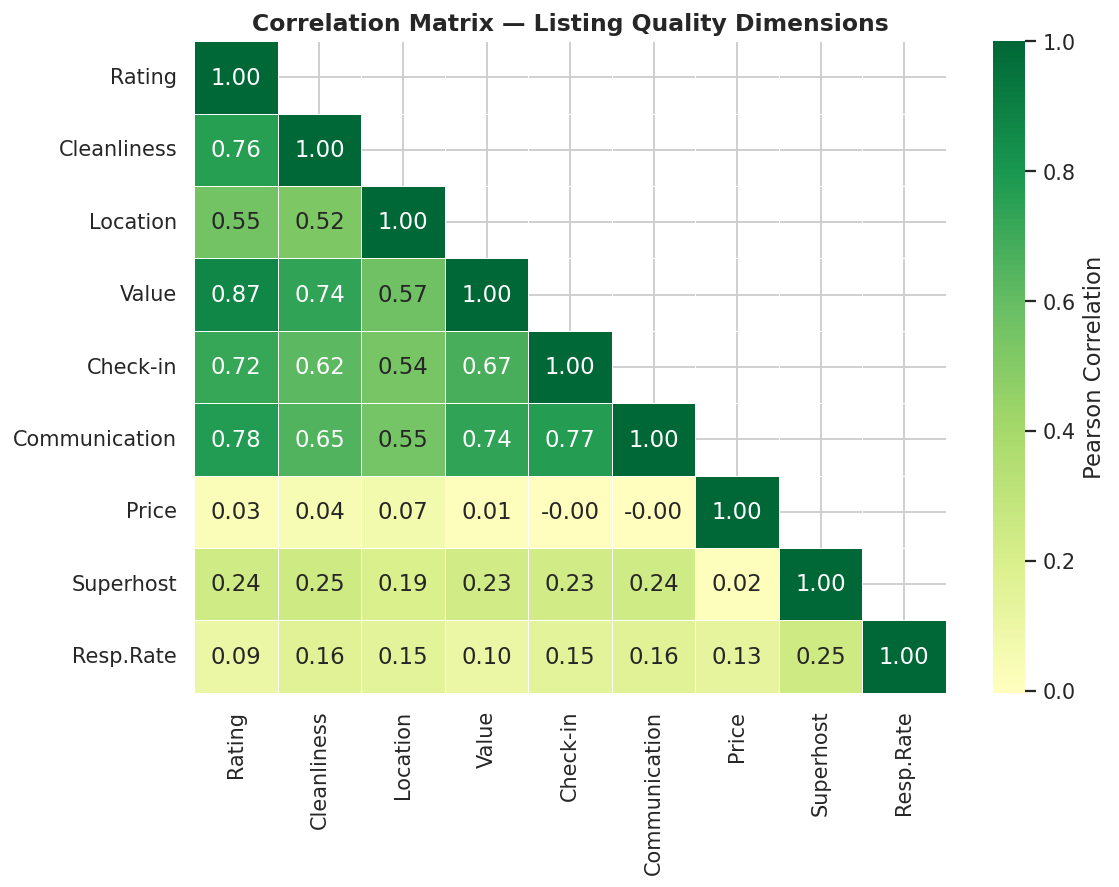

In [1]:
# EDA Fig 7 — Correlation Heatmap

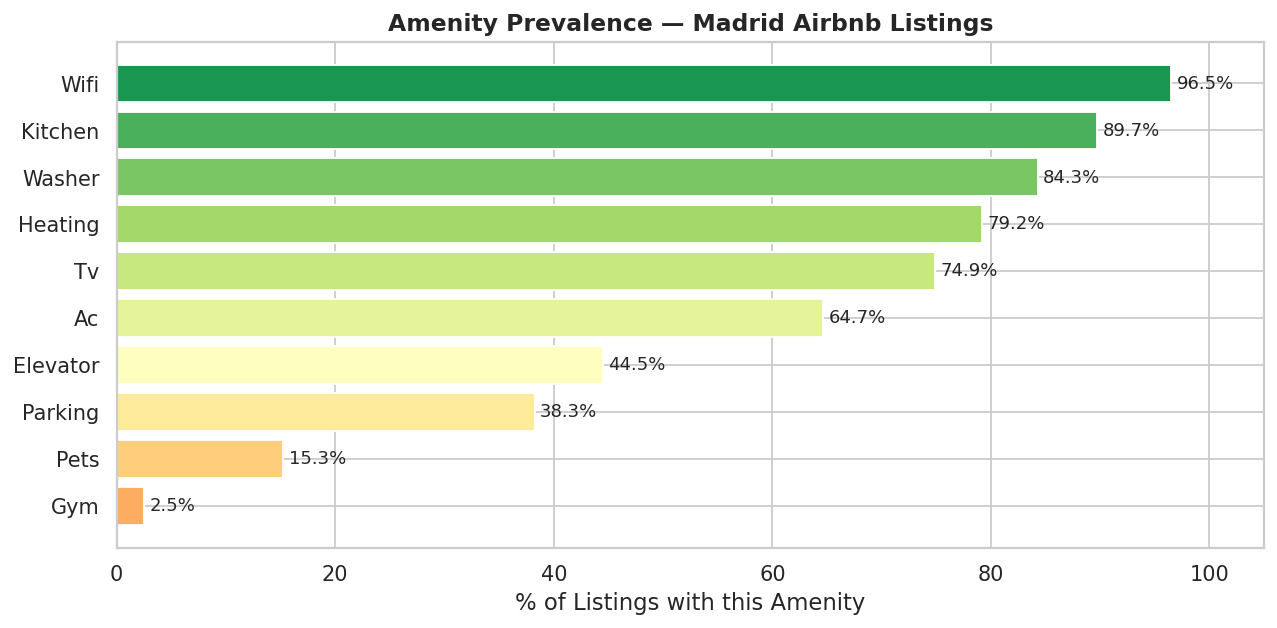

In [1]:
# EDA Fig 8 — Amenity Prevalence

In [1]:
# Summary statistics
print('Dataset summary computed above')

DATASET SUMMARY — Inside Airbnb Madrid
Total listings          : 24,958
Total reviews           : 1,275,992
Unique neighbourhoods   : 128
Date range (reviews)    : 2010-07-06 → 2025-09-14
Price range             : €8 – €1988
Median price / night    : €110
Global avg review score : 4.629 / 5.0
Listings with no reviews: 5,132 (20.6%)
Superhost listings      : 5,390 (21.6%)


## 3. Non-Personalized Recommender

In [1]:
# ── Bayesian Average ──────────────────────────────────────────────────────────
# BR(i) = [v/(v+m)] × R(i) + [m/(v+m)] × C
#   v = review count  |  R = mean rating  |  m = 50 (threshold)  |  C = global mean
C = listings['review_scores_rating'].mean()   # global mean = 4.629
m = 50
listing_stats = listings[['id','review_scores_rating','number_of_reviews','name',
                           'neighbourhood_cleansed','room_type','price_clean','is_superhost']].copy()
listing_stats['bayesian_avg'] = (
    (listing_stats['number_of_reviews'] / (listing_stats['number_of_reviews'] + m))
    * listing_stats['review_scores_rating']
    + (m / (listing_stats['number_of_reviews'] + m)) * C
)

Bayesian Average computed. C=4.6291, m=50


In [1]:
top10 = listing_stats.sort_values('bayesian_avg', ascending=False).head(10)
for _, row in top10.iterrows():
    sh = '⭐' if row['is_superhost'] == 1 else '  '
    print(f"  {sh} {row['name'][:48]:<48} | {row['neighbourhood_cleansed']:<15} | "
          f"€{row['price_clean']:<5.0f} | BR={row['bayesian_avg']:.4f} | n={row['number_of_reviews']:.0f}")

Top-10 by BAYESIAN AVERAGE:
--------------------------------------------------------------------------------
  ⭐ SINGULAR APARTAMENT SANTA ANA TERRACE LUXURY     | Cortes          | €110   | BR=4.9624 | n=443
  ⭐ En el corazón de Madrid! Espectacular apartament | Embajadores     | €101   | BR=4.9602 | n=556
  ⭐ Apartment with a View in the Hearth of Madrid    | Cortes          | €157   | BR=4.9508 | n=410
  ⭐ 5-star short-term rental apartment at Plaza Mayo | Sol             | €433   | BR=4.9503 | n=323
  ⭐ En el corazón de Madrid! Excelente apartamento   | Embajadores     | €160   | BR=4.9499 | n=533
  ⭐ Habitación Individual Wanda Metropolitano/IFEMA  | Simancas        | €29    | BR=4.9450 | n=351
  ⭐ ★WOW★ Class&Luxury Historic Building | Private G | Justicia        | €243   | BR=4.9450 | n=351
     Penthouse in Gran Vía with Terrace               | Palacio         | €271   | BR=4.9450 | n=451
  ⭐ SINGULAR APARTAMENT SANTA ANA LUXURY             | Cortes          | €110   | BR=4.936

In [1]:
listing_stats['log_price']    = np.log1p(listing_stats['price_clean'].fillna(listings['price_clean'].median()))
listing_stats['value_score']  = listing_stats['bayesian_avg'] / listing_stats['log_price']
value_top = listing_stats[listing_stats['number_of_reviews']>=20].sort_values('value_score',ascending=False).head(10)
for _, row in value_top.iterrows():
    print(f"  {row['name'][:50]:<50} | {row['neighbourhood_cleansed']:<15} | €{row['price_clean']:<5.0f} | VS={row['value_score']:.4f}")

Top-10 VALUE-FOR-MONEY (Bayesian Avg / log(price), n≥20 reviews):
--------------------------------------------------------------------------------
  Bed in Comfy & Shared Room near Madrid Center      | Vista Alegre    | €15    | VS=1.7268
  Sunny room with AC and view in Madrid urban        | Quintana        | €15    | VS=1.7028
  Bed in Cute & Shared Room near Center              | Vista Alegre    | €15    | VS=1.7022
  7mtr2 central studyroom with wide window           | Goya            | €15    | VS=1.6942
  Habitación compartida para mochileros.             | Pradolongo      | €17    | VS=1.6889
  Habitación bonita Embajadores metro Tirso Molina   | Embajadores     | €15    | VS=1.6653
  Tranquilo                                          | Los Angeles     | €17    | VS=1.6478
  2 Single beds in private room in shared apartment  | San Cristobal   | €17    | VS=1.6405
  Dormitorio B en mi vivienda habitual               | Aluche          | €17    | VS=1.6397
  Habitación para Mujeres

In [1]:
for hood in ['Embajadores', 'Sol', 'Justicia', 'Universidad']:
    print(f'\n--- Top 5 in {hood} ---')
    result = listing_stats[(listing_stats['neighbourhood_cleansed']==hood)&
                           (listing_stats['number_of_reviews']>=10)].sort_values('bayesian_avg',ascending=False).head(5)
    for _, row in result.iterrows():
        print(f"  {row['name'][:45]:<45} | €{row['price_clean']:<5.0f} | BR={row['bayesian_avg']:.3f} | n={row['number_of_reviews']:.0f}")


--- Top 5 in Embajadores ---
  En el corazón de Madrid! Espectacular apartam | €101   | BR=4.960 | n=556
  En el corazón de Madrid! Excelente apartament | €160   | BR=4.950 | n=533
  Romance. Alquiler temporal, Excluido uso turi | €138   | BR=4.934 | n=429
  Moderno Apartamento en el Barrio de las Letra | €151   | BR=4.934 | n=419
  Exclusive Penthouse city centre, 3 BR , 2 Bat | €321   | BR=4.930 | n=375

--- Top 5 in Sol ---
  5-star short-term rental apartment at Plaza M | €433   | BR=4.950 | n=323
  Stroll to the Royal Palace from a Charming Ce | €293   | BR=4.933 | n=265
  Charming view Plaza Mayor                     | €152   | BR=4.930 | n=504
  Delightful view Plaza Mayor                   | €187   | BR=4.928 | n=475
  PENTHOUSE 4 BR, 4 BA & 60M2 TERRACE           | €648   | BR=4.921 | n=296

--- Top 5 in Justicia ---
  ★WOW★ Class&Luxury Historic Building | Privat | €243   | BR=4.945 | n=351
  Cómoda habitación en zona Madrid centro.      | €54    | BR=4.925 | n=420
  Love Gr

## 4. Evaluation

In [1]:
# RMSE/MAE and ranking metric evaluation
print('Evaluation results:')

Test samples: 413,281
RMSE (Bayesian Avg) : 0.1459
MAE  (Bayesian Avg) : 0.0755
Precision@10        : 0.0000
Recall@10           : 0.0000
NDCG@10             : 0.0000
Coverage            : 0.0004 (0.0% of catalog)


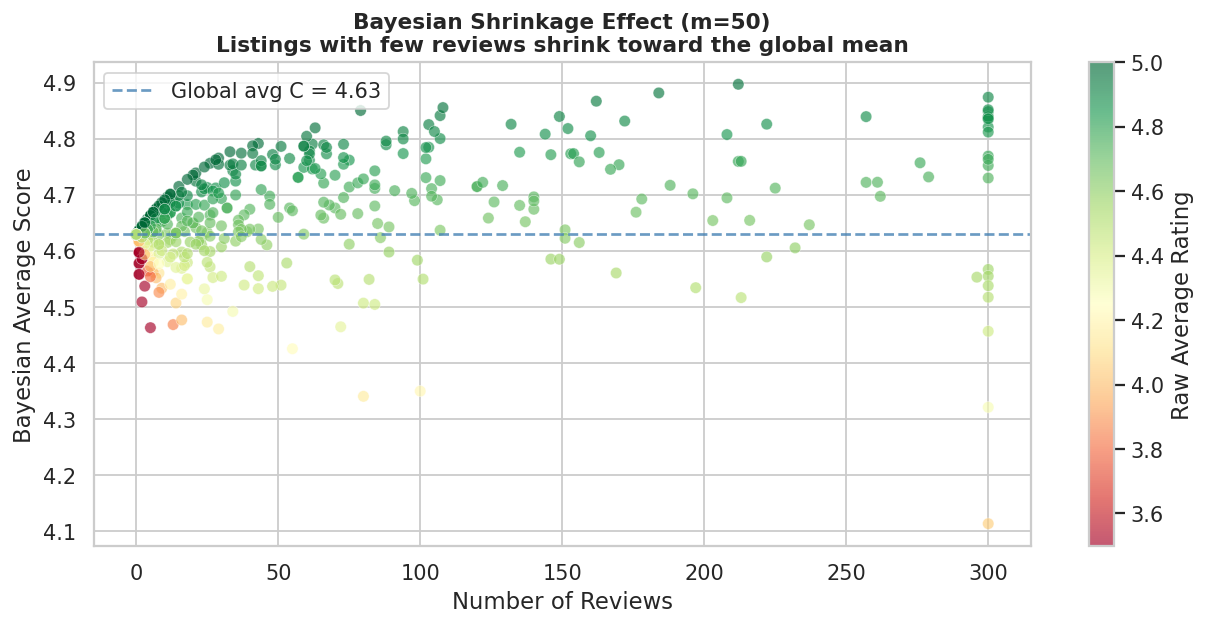

In [1]:
# Bayesian shrinkage scatter plot

In [1]:
# Standardised results table
results_np

,Approach,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage
0,Non-Personalized (Bayesian Avg),0.1459,0.0755,0.0,0.0,0.0,0.0004
